# Data Mining

## Preamble

### Modules

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import plotly.express as px
import plotly.io as pio
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from itertools import combinations
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

from utils.utils import load_and_drop_na_data

### Loading Data

In [2]:
df = load_and_drop_na_data('../data/transformed/transformed.csv')

Raw data: 406585 rows
Removed 5223 duplicates
Clean data: 401362 rows


In [3]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

### Configuration

In [5]:
pio.renderers.default = 'notebook_connected'

## Market Basket Analysis

### Preamble

The algorithm that will be used is the Apriori algorithm.

The following terms will be used:

- _itemset_: This represents a collection of one or more items.
- _transaction_: This represents an itemset purchased by a single user with an attached InvoiceNo.

### Objective

The aim of this analysis is to evaluate over multiple transactions the precursor itemset $X$ and successor itemset $Y$ and their correlation. That is, if an itemset $X$ is bought how does it affect the purchase of an itemset. The correlation can be:

- **Positive:** When $X$ is bought then $Y$ is likely to be bought in a certain percentage of transactions. That is, purchasing $X$ encourages customers to purchase $Y$. 
- **Negative:** When $X$ is bought then $Y$ is unlikely to be bought in a certian percentage of transactions. That is, purchasing $Y$ discourages customers from purchasing $Y$.
- **Neutral:** When $X$ is bought there is no influence on the purchase of $Y$.

This correlation is mapped out by three variables:

- Support
- Confidence
- Lift

Lift is used to handle the possibility of a spurious correlation between $X$ and $Y$.

### Key Metrics

#### Support

This is the fraction of transactions containing $X$:

$$\mathrm{supp}(X) = \frac{\lvert \{\,t \mid X \subseteq t\} \rvert}{\lvert \text{Transactions} \rvert}$$

For a rule $X \Rightarrow Y$:

$$\mathrm{supp}(X \cup Y)$$

#### Confidence

This is the probability that Y will occur given X:

$$\mathrm{conf}(X \Rightarrow Y) = P(Y \mid X) = \frac{\mathrm{supp}(X \cap Y)}{\mathrm{supp}(X)}$$

It focuses on reflecting how reliable the implication is.

#### Lift

It measures how much more often $X$ and $Y$ occur together than if independent.

This handles the scenario where both $X$ and $Y$ are popular. The support and confidence can make it seem that $X$ has a positive effect on $Y$ when in reality $Y$ is actually really popular and its sales are from its own popularity.

$$\mathrm{lift}(X \Rightarrow Y) = \frac{\mathrm{supp}(X \cap Y)}{\mathrm{supp}(X)\cdot \mathrm{supp}(Y)}
= \frac{\mathrm{conf}(X \Rightarrow Y)}{\mathrm{supp}(Y)}$$

- Lift > 1 -> Positive association
- Lift = 1 -> Independence
- Lift < 1 -> Negative association

Independence in this case means that $X$ has no impact on $Y$ and that they are both popular or unpopular on their own.

### Visual Illustrations

#### Support

<img src="https://miro.medium.com/max/403/0*pyOADkeaWyrVP2ft.png" />

#### Simulated Transactions

<img src='https://annalyzin.files.wordpress.com/2016/04/association-rule-support-table.png?w=503&h=447' />

#### Confidence

<img src='https://miro.medium.com/max/576/1*50GI4dR58MnhwBP9dw6nFQ.png' />

<img src='https://annalyzin.files.wordpress.com/2016/03/association-rule-confidence-eqn.png?w=527&h=77' />

#### Lift

<img src='https://annalyzin.files.wordpress.com/2016/03/association-rule-lift-eqn.png?w=566&h=80' />

### Apriori Algorithm

The transactions are placed in a one-hot encoded format where they are aggregated based on their `InvoiceNo` and placed in a list of lists. Each list within the main list represents a single transaction done by a particular customer at a particular time.

In [6]:
apriori_df = df.dropna(subset=["InvoiceNo", "Description"])

apriori_df["Description"] = apriori_df["Description"].str.strip().str.lower()

transactions = apriori_df.groupby("InvoiceNo")["Description"].apply(list).tolist()

The first two transactions are shown for validation that the one-hot encoded format has been used.

In [7]:
transactions[:2]

[['white hanging heart t-light holder',
  'white metal lantern',
  'cream cupid hearts coat hanger',
  'knitted union flag hot water bottle',
  'red woolly hottie white heart.',
  'set 7 babushka nesting boxes',
  'glass star frosted t-light holder'],
 ['hand warmer union jack', 'hand warmer red polka dot']]

The transactions are then encoded into a Pandas dataframe where each cell entry is either True or False. When the cell entry is:

- **True:** The particular transaction has that item being purchased.
- **False:** The particular transaction does not have that item being purchased.

In [8]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
apriori_df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

The first 5 rows are show for validation.

In [9]:
apriori_df_encoded.head()

,10 colour spaceboy pen,12 coloured party balloons,12 daisy pegs in wood box,12 egg house painted wood,12 hanging eggs hand painted,12 ivory rose peg place settings,12 message cards with envelopes,12 pencil small tube woodland,12 pencils small tube red retrospot,12 pencils small tube skull,...,zinc star t-light holder,zinc sweetheart soap dish,zinc sweetheart wire letter rack,zinc t-light holder star large,zinc t-light holder stars large,zinc t-light holder stars small,zinc top 2 door wooden shelf,zinc willie winkie candle stick,zinc wire kitchen organiser,zinc wire sweetheart letter tray
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


The minimum support is set at **0.015** which corresponds to **1.5%** of the dataset. This means that any itemset appearing in **6,000** or more transactions is considered frequent. This is a safe balanced choice.

In [10]:
frequent_itemsets = apriori(apriori_df_encoded, min_support=0.015, use_colnames=True)

The itemsets are then sorted to ensure that the itemsets with the highest support bubble to the top.

In [11]:
frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False).reset_index(drop=True)

The number of itemsets are shown to ensure that the number is reasonable to allow for association rules. Moreover, the first 5 rows of the frequent itemsets are shown for the sake of validation.

In [12]:
print(f"There are {len(frequent_itemsets)} frequent itemsets")

There are 316 frequent itemsets


In [13]:
frequent_itemsets[:5]

,support,itemsets
0,0.090749,(white hanging heart t-light holder)
1,0.084844,(regency cakestand 3 tier)
2,0.074069,(jumbo bag red retrospot)
3,0.063069,(party bunting)
4,0.062303,(assorted colour bird ornament)


The association rules are generated with a focus on `lift` with a minimum threshold of `1`. This threshold is selected since itemsets with lift threshold exceeding 1 show a positive correlation between the two itemsets.

In [14]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1).sort_values(by="lift", ascending=False).reset_index(drop=True)

The first 5 rows are displayed for validation

In [15]:
rules.head(5)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(roses regency teacup and saucer, green regenc...",(pink regency teacup and saucer),0.025110,0.026643,0.017897,0.712747,26.751524,1.0,0.017228,3.388498,0.987413,0.528628,0.704884,0.692245
1,(pink regency teacup and saucer),"(roses regency teacup and saucer, green regenc...",0.026643,0.025110,0.017897,0.671743,26.751524,1.0,0.017228,2.969895,0.988968,0.528628,0.663288,0.692245
2,"(pink regency teacup and saucer, roses regency...",(green regency teacup and saucer),0.020332,0.033045,0.017897,0.880266,26.638557,1.0,0.017226,8.075866,0.982435,0.504447,0.876174,0.710938
3,(green regency teacup and saucer),"(pink regency teacup and saucer, roses regency...",0.033045,0.020332,0.017897,0.541610,26.638557,1.0,0.017226,2.137193,0.995352,0.504447,0.532097,0.710938
4,(pink regency teacup and saucer),(green regency teacup and saucer),0.026643,0.033045,0.021233,0.796954,24.117381,1.0,0.020353,4.762254,0.984774,0.552169,0.790015,0.719760


The antecedents are converted from `frozenset` to `string` which is a JSON serializable format.

In [16]:
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

The scatter plot of the `support` against `confidence` is displayed to check for correlation.

In [17]:
fig = px.scatter(
    rules,
    x="support",
    y="confidence",
    size="lift",
    color="lift",
    hover_data=["antecedents_str", "consequents_str"],
    title="Association Rules: Support vs Confidence (size = lift)"
)

In [18]:
fig.show()

## Clustering

### Preamble

The clustering approach will be customer segmentation, grouping customers based on aggregated transactional behaviour like:

- Purchase Frequency
- Recency
- Monetary Value

The K-Means Clustering algorithm will be employed due to:

- The size of the dataset
- The aim of finding homogenous clusters of customer behaviour

It should be noted that $K$ represents some number of clusters uncovered by the clustering model.

### Understanding the Algorithm

K-Means is an **unsupervised centroid-based** clustering that partitions the customers into K clusters where each point belongs to the cluster with the **nearest mean**.

The algorithm seeks to minimize the **within-cluster sum of squares (WCSS)**. That is the sum of squared distances between each point and its cluster centroid.

Mathematically, this is expressed as follows:

$$\min_{\{S_i\}_{i=1}^K} \sum_{i=1}^{K} \sum_{\mathbf{x} \in S_i} \lVert \mathbf{x} - \boldsymbol{\mu}_i \rVert^2$$

Where:

$$\boldsymbol{\mu}_i = \frac{1}{\lvert S_i \rvert} \sum_{\mathbf{x} \in S_i} \mathbf{x}$$

With $S_1$ being the set of points in cluster $i$ and $\mu_{i}$ its centroid.

### Suitability

K-Means is suitable since:

- It considers the numerical features derived
- It produces exclusive clusters with each customer belonging to only one segment
- The results are directly actionable since clusters can be labelled as "high spenders", "frequent buyers" or "low frequency visitors" enabling strategies to be tailored accordingly.

### K-Means Clustering Algorithm

The `kmeans_df` is created as a copy of the original dataframe and a computed column of `TotalPrice` is prepared to be used as the column that determines the clustering criteria.

The K-Means Clustering Algorithm will be used to uncover the groups of customers who purchase from the store and their spending habits.

In [19]:
kmeans_df = df.copy()
kmeans_df['TotalPrice'] = kmeans_df['Quantity'] * kmeans_df['UnitPrice']

The first 5 rows are displayed for validation.

In [20]:
kmeans_df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


The dataframe is aggregated based on the customers purchasing from the store with the first 5 rows being shown for validation.

In [21]:
customer_kmeans_df = kmeans_df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',                  # Number of transactions
    'Quantity': 'sum',                       # Total items bought
    'TotalPrice': 'sum',                     # Total amount spent
    'UnitPrice': 'mean',                     # Average unit price
}).rename(columns={
    'InvoiceNo': 'NumTransactions',
    'Quantity': 'TotalItems',
    'TotalPrice': 'TotalSpent',
    'UnitPrice': 'AvgUnitPrice'
}).sort_values(by="NumTransactions", ascending=False).reset_index()

In [22]:
customer_kmeans_df.head(5)

,CustomerID,NumTransactions,TotalItems,TotalSpent,AvgUnitPrice
0,14911.0,248,83825,155590.31,5.262821
1,12748.0,224,26826,37702.07,3.296605
2,17841.0,169,23040,41170.63,2.554579
3,14606.0,128,6433,12518.95,2.819304
4,15311.0,118,38621,61981.31,2.520218


The customer dataframe is then autoscaled using a `StandardScaler` and predefined features.

In [23]:
features = ['NumTransactions', 'TotalItems', 'TotalSpent', 'AvgUnitPrice']
X = customer_kmeans_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

The number of clusters selected are `4` with a random state of `42` for reproducibility.

In [24]:
kmeans = KMeans(n_clusters=4, random_state=42)
customer_kmeans_df['Cluster'] = kmeans.fit_predict(X_scaled)

The pairplot is the displayed to show the economic behaviour of customers dependent on their clusters.

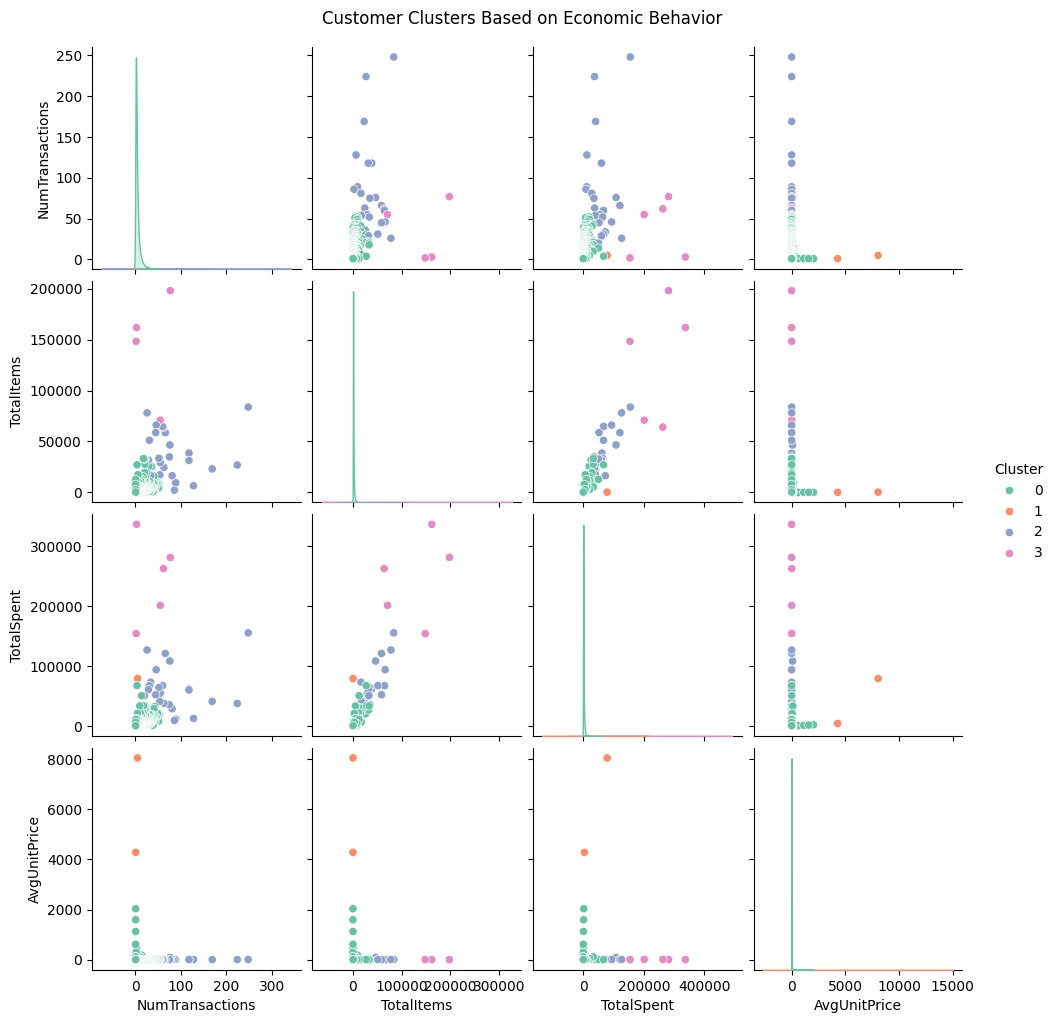

In [25]:
sns.pairplot(customer_kmeans_df, vars=features, hue='Cluster', palette='Set2')
plt.suptitle("Customer Clusters Based on Economic Behavior", y=1.02)
plt.show()

Finally, a cluster summary is displayed based on the `mean` of each customer cluster.

In [26]:
cluster_summary = customer_kmeans_df.groupby('Cluster')[features].mean()
print(cluster_summary)

         NumTransactions     TotalItems     TotalSpent  AvgUnitPrice
Cluster                                                             
0               4.607793     901.894628    1548.436605      5.161208
1               3.000000      91.500000   41735.565000   6171.705000
2              83.041667   36736.916667   61432.276667      6.999542
3              39.800000  128749.600000  247450.944000      5.355333


From this summary the customers can be categorised into:

- Cluster `0`: **Low-Value Occasional Buyers**
- Cluster `1`: **High-End Luxury Shoopers**
- Cluster `2`: **Frequent High-Volume Buyers**
- Cluster `3`: **Elite Bulk Buyers**

## High Utility Itemset Mining

### Preamble

High Utility Itemset Mining **(HUIM)** identifies the most valuable combination of products in the data considering both the quantity and price. The focus in this particular algorithm is locating the most econmomically viable itemsets.

### Objective

This algorithm handles the blind spot of frequent itemset identification. That is, a frequent itemset can be of little economic value. Or an infrequent itemset can be of great economic value.

Utilising only the frequent itemset algorithm may have a business stocking up on items that although bought often do not translate into tangible economic benefits.

However, incorporating both algorithms uncovers the following groups:

- Frequent High Value Itemsets
- Frequent Low Value Itemsets
- Infrequent High Value Itemsets
- Infrequent Low Value Itemsets

This discovery allows a business to focus more on their frequent high value itemsets enabling them to greatly increase their profit margins.

### BTS of the Algorithm

The utility of an item $i$ in a transaction is:

$$utility(i, t) = quantity_{i,t} \times unit\_price_{i, t}$$

The utility itemset $X$ in transaction $t$ is:

$$u(X, t) = \sum_{i \in X} u(i, t)$$

The total utility of $X$ across the dataset is:

$$U(X) = \sum_{t \in D\;:\;X \subseteq t} u(X, t)$$

### HUIM Algorithm

The `huim_df` is created as a copy of the original dataframe and a column `Utility` added with the first 5 rows being displayed for validation.

In [27]:
huim_df = df.copy()
huim_df['Utility'] = huim_df['Quantity'] * huim_df['UnitPrice']

In [28]:
huim_df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Utility
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


A utility matrix is created similar to the Apriori algorithm but the cell values are either the utility of a particular product if it is found in the particular transaction or zero otherwise. Moreover, the first 5 rows are displayed for validation.

In [29]:
utility_matrix = huim_df.pivot_table(
    index='InvoiceNo',
    columns='Description',
    values='Utility',
    aggfunc='sum',
    fill_value=0
)

In [30]:
utility_matrix.head(5)

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The utility of items is determined by sorting values and setting a threshold of `10,000` to find only the most valuable items.

In [31]:
item_utilities = utility_matrix.sum().sort_values(ascending=False)

utility_threshold = 10000  # Set based on your dataset
high_utility_items = item_utilities[item_utilities > utility_threshold]
print(high_utility_items)

Description
PAPER CRAFT , LITTLE BIRDIE           336939.20
Manual                                169791.84
MEDIUM CERAMIC TOP STORAGE JAR        158896.37
REGENCY CAKESTAND 3 TIER              152063.80
WHITE HANGING HEART T-LIGHT HOLDER    107016.40
                                        ...    
SOLDIERS EGG CUP                       10203.00
GARDENERS KNEELING PAD CUP OF TEA      10165.29
REVOLVER WOODEN RULER                  10126.14
LUNCH BAG VINTAGE LEAF DESIGN          10058.55
TRADITIONAL WOODEN SKIPPING ROPE       10036.49
Length: 195, dtype: float64


The utility matrix is then filtered to retain only the combinations of itemsets that are high value itemsets. Moroever, the first 5 rows are displayed for validation.

In [32]:
# Keep only high utility columns
filtered_huim_matrix = utility_matrix[high_utility_items.index]

# Generate 2-item combinations
itemsets = list(combinations(filtered_huim_matrix.columns, 2))

# Compute utility of each itemset
high_utility_itemsets = {}
.
for item1, item2 in itemsets:
    total_utility = (filtered_huim_matrix[item1] + filtered_huim_matrix[item2]).sum()
    if total_utility > utility_threshold:
        high_utility_itemsets[(item1, item2)] = total_utility

# View top itemsets
high_utility_itemsets = dict(sorted(high_utility_itemsets.items(), key=lambda x: x[1], reverse=True))
df_huim_utility = pd.DataFrame(
    [(items, utility) for items, utility in high_utility_itemsets.items()],
    columns=["Itemset", "Utility"]
)

SyntaxError: invalid syntax (1421800025.py, line 9)

In [ ]:
df_huim_utility.head(5)

## Time Series

### Preamble

The **Auto-Regressive Integrated Moving Average (ARIMA)** algorithm will be employed.

The model works based on three combined components:

- **AR** models the series using its own past values
- **I** uses differencing to make a non-stationary series stationary
- **MA** models the current value of the series as a function of past forecast errors

### Objective

This enables:

- Revealing trends, seasonality and irregular patterns
- Forecasting future demand to optimize inventory and marketing
- Detecting seasonal cycles like weekly or holiday spikes
- Identifying anomalies which could indicate fraud, data issues or promotional impacts

### Deconstructing the Algorithm

To make the series stationary- that is, having a constant mean and variance- differencing is applied:

$$y'_t = y_t - y_{t-1}$$

Higher-order differencing may also be applied depending on the complexity of the data. Moreover, seasonal differencing may prove invaluable in when the aim is to group time intervals.

The current vaue is modelled after past values in the Auto-Regressive phase:

$$X_t = \sum_{i=1}^{p} \varphi_i X_{t-i} + \varepsilon_t$$

For the Moving Average the current value is modelled based on past forecast errors:

$$X_t = \varepsilon_t + \sum_{i=1}^{q} \theta_i \varepsilon_{t-i}$$

When all of this is put together the combined **ARIMA(p, d, q)** model using the lag operator $L$ with an optional constant term representing drift has the general form:

$$\left(1 - \sum_{i=1}^p \varphi_i L^i\right) (1 - L)^d X_t = \delta + \left( 1 + \sum_{i=1}^{q} \theta_i L^i \right) \varepsilon_t$$

Finally the fitted model is used to project future values and compute forecast intervals, usually:

$$\hat y_{T+h|T} \; \pm \; 1.96 \sqrt{v_{T+h|T}}$$

Where $v_{T+h|T}$ is the forecast variance.

### ARIMA Model

The `arima_df` is created as a copy of the original dataframe and a column `Revenue` added with the first 5 rows being displayed for validation.

In [ ]:
arima_df = df.copy()
arima_df['Revenue'] = arima_df['Quantity'] * arima_df['UnitPrice']

In [ ]:
arima_df.head(5)

The `InvoiceDate` column is converted to DateTime with incompatible rows being dropped.

In [ ]:
arima_df['InvoiceDate'] = pd.to_datetime(arima_df['InvoiceDate'], errors='coerce')
arima_df = arima_df.dropna(subset=['InvoiceDate'])

The index is set as the `InvoiceDate` column with the modification happening `inplace`. The type of the index is validated to avoid TypeErrors. The expected index type is `DateTimeIndex`.

In [ ]:
arima_df.set_index('InvoiceDate', inplace=True)
print(type(arima_df.index))

The dataframe is then resampled based on the `Revenue` column with the operation being sum.

In [ ]:
ts = arima_df['Revenue'].resample('D').sum()
ts = ts.fillna(0)

The `Augmented-Dickey Fuller` test is applied to check for the non-stationary nature of the data. The hypotheses under examination are:

- **Null Hypothesis:** The time series has a unit root (i.e. it is non-stationary).
- **Alternative Hypothesis:** The time series is stationary.

In [ ]:
result = adfuller(ts)
print('ADF stat:', result[0])
print('p-value:', result[1])

The `p-value` of **0.9** is significantly higher then **0.05** thus we **fail to reject the null hypothesis**.

Due to the non-stationary nature of the data it needs to be differenced. After differencing the **autocorrelation** and **partial autocorrelation** are visualised.

In [ ]:
ts_diff = ts.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pacf(ts_diff, lags=30, ax=axes[1])
plot_acf(ts_diff, lags=30, ax=axes[0])
plt.show()

Based on th `ACF` and `PACF` graphs the suitable `(p, d, q)` are:

- PACF (15) -> `p`
- Non-Stationary (1) -> `d`
- ACF (27.5) -> `q`

In the `(p, d, q)` the values are rounded down to the nearest whole number.

$$(p, d, q) = (15, 1, 27)$$

However such values make the model too complex and instead the lag before the very first point that falls within the confidence intervals will be used. In this case, it simplifies the model to:

$$(p, d, q) = (4, 1, 3)$$

In [ ]:
p, d, q = 4, 1, 3  # Example – adjust based on ACF/PACF
model = ARIMA(ts, order=(p, d, q))
model_fit = model.fit()
print(model_fit.summary())

The significant terms are:

- AR(1)
- AR(2)
- MA(3)

This means that the model can be simplified to:

$$(p, d, q) = (2, 1, 3)$$

In [ ]:
p, d, q = 2, 1, 3  # Example – adjust based on ACF/PACF
model = ARIMA(ts, order=(p, d, q))
model_fit = model.fit()
print(model_fit.summary())

In [ ]:
n_steps = 30
forecast = model_fit.forecast(steps=n_steps)

# Visualize
plt.figure(figsize=(10, 5))
plt.plot(ts, label='History')
plt.plot(forecast, label=f'Forecast next {n_steps} days', color='red')
plt.legend()
plt.show()

The model predicts that the sales will a decrease from the peak and an assumption of a slightly higher yet greatly similar sales volume akin to the the historical transactions.

In [ ]:
train, test = ts[:-n_steps], ts[-n_steps:]
model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()
preds = model_fit.forecast(steps=n_steps)

In [ ]:
# Evaluate
mae = mean_absolute_error(test, preds)
rmse = root_mean_squared_error(test, preds)
print(f'MAE: {mae:.2f}, RMSE: {rmse:.2f}')

The model makes mistakes of predicting the values of items from between **27,000** and **61,000**.

Based on the large sales volumes that are present and a glance at the graph it is evident that although the model may require a little more fine-tuning it is fairly accurate.